In [1]:
import numpy as np
from scipy.optimize import minimize
from IPython.display import clear_output
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.linalg import svdvals

rc = {"font.family" : "Times New Roman", 
      "mathtext.fontset" : "stix"}
plt.rcParams.update(rc)

from QAOA import *
from hamiltonians import *
from heuristics import *
from visualization import *
from analysis import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
def get_singular(n,p,p_max,n_instances,path,fdata,k_max=20,qaoa=0,coupling_mat=None):
    
    path = path + str(n)+ 'q/'
    
    d = 2*p   
    
    S = np.zeros((k_max,n_instances))

    for index in range(1,n_instances+1):

        fname = str(n) + fdata + str(index) + '.txt'

        if qaoa:
            
            weights = list(np.genfromtxt(path+fname,skip_header=1,skip_footer=2*p_max))

            H2 = get_hamiltonian(n,weights)
            Q = QAOA(p,H2,H2)
            
        else:

            A = np.genfromtxt(path+fname,skip_header=2,skip_footer=2*p_max)
            weights = list(np.genfromtxt(path+fname,skip_header=1,skip_footer=2*p_max+1))

            H1 = ion_native_hamiltonian(n,A,coupling_mat)
            H2 = get_hamiltonian(n,weights)
            Q = QAOA(p,H1,H2)

        sv_matrix = np.zeros((k_max,2**n),dtype=np.complex128)

        for k in range(k_max):
            angles = [np.random.uniform(0,2.0*np.pi)]*p +  [np.random.uniform(0,0.5*np.pi)]*p
            #angles  = np.random.uniform(0,np.pi,size=d)
            sv_matrix[k,:] = Q.qaoa_ansatz(angles).reshape(-1)
    
        S[:,index-1] = svdvals(sv_matrix)

    S_avg = np.mean(S,axis=1)
    S_std = np.std(S,axis=1)
        
    return S_avg, S_std

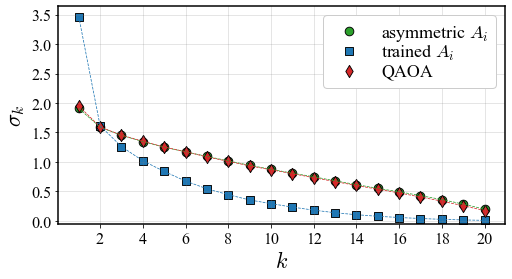

In [3]:
n = 6
n_instances = 100
p = 10
p_max = 10
k_max = 20

# ions chain parameters
nu_rad = 1e6
nu_ax = 0.15e6
mu = 2*np.pi*(nu_rad + 10e3) # in Hz
Omega_max = 2*np.pi*30e3     # in Hz

coupling_mat = radial_coupling_matrix(n, nu_rad, nu_ax, mu, Omega_max) # in kHz

kk = np.array(range(1,k_max+1))

S_ion_avg, S_ion_std = get_singular(n,p,p_max,n_instances,path='data/cycle4/',fdata='q_lw_',k_max=k_max,qaoa=0,coupling_mat=coupling_mat)
S_qaoa_avg, S_qaoa_std = get_singular(n,p,p_max,n_instances,path='data_qaoa/',fdata='q_qaoa_',k_max=k_max,qaoa=1)
S_asym_avg, S_asym_std = get_singular(n,p,p_max,n_instances,path='data/cycle4/',fdata='q_lw_asym_',k_max=k_max,qaoa=0,coupling_mat=coupling_mat)

data_asym = np.zeros((k_max,3))
data_asym[:,0] = kk
data_asym[:,1] = S_asym_avg
data_asym[:,2] = S_asym_std

data_ion = np.zeros((k_max,3))
data_ion[:,0] = kk
data_ion[:,1] = S_ion_avg
data_ion[:,2] = S_ion_std

data_qaoa = np.zeros((k_max,3))
data_qaoa[:,0] = kk
data_qaoa[:,1] = S_qaoa_avg
data_qaoa[:,2] = S_qaoa_std

data_sets = [data_asym, data_ion, data_qaoa]
labels = ['asymmetric $A_i$', 'trained $A_i$', 'QAOA']
markers = ['o', 's', 'd', 'v', 'p', 'H']
colors = ['tab:green', 'tab:blue', 'tab:red', 'tab:orange', 'tab:brown', 'tab:cyan']

plot_data(data_sets,labels,markers,colors,ylabel='$\sigma_{k}$',ymin=-0.05,ncol=1,loc=0,log=0,h=0.4)

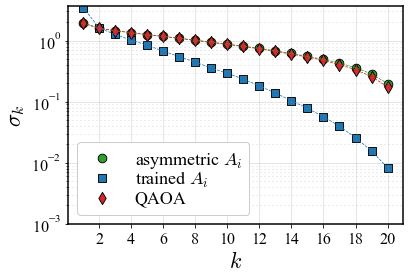

In [4]:
plot_data(data_sets,labels,markers,colors,ylabel='$\sigma_{k}$',ymin=1e-3,ncol=1,loc=0,log=1,h=0.3)